In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn.model_selection import KFold,cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [4]:
df = pd.read_csv("surface_wqi_pred.csv")

df.head()

,Site,Year,pH,Odour,Turbidity,Conductivity,Chloride (ppm),Sulphates(ppm),Iron (ppm),COD(ppm),...,Ammonia(ppm),Nitrate(ppm),Fluorides(ppm),Phosphates(ppm),Total Bacterial Count (cfu/ml),Total Fungal Count (cfu/ml),Pesticide (µg/l),WQI,WQI_Class,WQI_Pred
0,Karan Lake (Site 1) (Surface Water),2016,6.70,NaN,4.30,482,19.0,75.0,16.60,32.1,...,0.3,9.0,NaN,NaN,500,NaN,NaN,63.789474,Medium,NaN
1,Karan Lake (Site 1) (Surface Water),2017,6.80,NaN,5.80,445,19.0,71.0,16.00,34.2,...,0.3,9.0,NaN,NaN,500,NaN,NaN,57.894737,Medium,NaN
2,Karan Lake (Site 1) (Surface Water),2018,7.10,NaN,5.80,442,19.7,71.0,15.80,41.9,...,0.5,11.0,NaN,5.0,500,NaN,NaN,54.035088,Medium,NaN
3,Brahma Sarovar(Site 2) Surface Water,2016,7.47,NaN,1.99,582,12.6,85.0,15.05,84.2,...,0.0,5.0,NaN,NaN,1200,300.0,NaN,65.101754,Medium,NaN
4,Brahma Sarovar(Site 2) Surface Water,2017,6.20,NaN,2.30,634,13.0,90.0,13.55,86.2,...,0.3,15.0,NaN,NaN,1300,300.0,NaN,80.631579,Good,68.382807


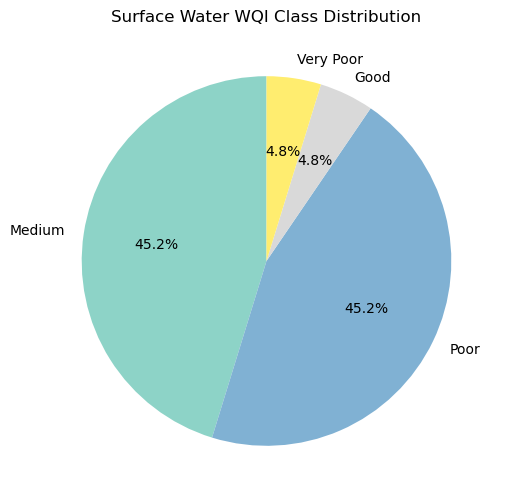

In [32]:
#PIE CHART: CLASS DISTRIBUTION
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df["WQI_Class"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    cmap="Set3"
)

plt.title("Surface Water WQI Class Distribution")

plt.ylabel("")

plt.show()

In [15]:
#ENCODE CLASSES

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["WQI_Class_Encoded"] = le.fit_transform(df["WQI_Class"])

In [16]:
#FEATURE CLASSES
# Remove object columns
X = df.select_dtypes(include="number").drop(columns=["WQI", "WQI_Class_Encoded"])

# Remove columns with all NaN values
X = X.dropna(axis=1, how='all')

# Target variable
y = df["WQI_Class_Encoded"]

# Impute missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [17]:
#TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
#SCALING
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
#MODELS
models = {

"Random Forest": RandomForestClassifier(random_state=42),
"Gradient Boosting": GradientBoostingClassifier(random_state=42),
"SVM": SVC(),
"KNN": KNeighborsClassifier(),
"Decision Tree": DecisionTreeClassifier(random_state=42),
"XGBoost": XGBClassifier(eval_metric="mlogloss")

}

In [22]:
#TRAIN MODELS + METRICS
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)

    results.append([name, acc, precision, recall, f1, mcc])

D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\a

In [21]:
print(y.head())
print(type(y.iloc[0]))

0    1
1    1
2    1
3    1
4    0
Name: WQI_Class_Encoded, dtype: int32
<class 'numpy.int32'>


In [30]:
# K FOLD CROSS VALIDATION
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

final_results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_test, y_pred)

    cv5 = cross_val_score(model, X, y, cv=kf5, scoring="accuracy")
    cv10 = cross_val_score(model, X, y, cv=kf10, scoring="accuracy")

    final_results.append([
        name,
        acc,
        precision,
        recall,
        f1,
        mcc,
        f"{cv5.mean():.3f} ± {cv5.std():.3f}",
        f"{cv10.mean():.3f} ± {cv10.std():.3f}"
    ])

D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\Sukhmanpreet Kaur\a

In [31]:
columns = [
"Model",
"Accuracy",
"Precision",
"Recall",
"F1 Score",
"MCC",
"5-Fold Accuracy",
"10-Fold Accuracy"
]

results_df = pd.DataFrame(final_results, columns=columns)

results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,MCC,5-Fold Accuracy,10-Fold Accuracy
4,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.928 ± 0.099,0.930 ± 0.155
1,Gradient Boosting,0.888889,0.800000,0.888889,0.839506,0.821584,0.906 ± 0.048,0.910 ± 0.111
0,Random Forest,0.777778,0.688889,0.777778,0.728395,0.616188,0.858 ± 0.089,0.815 ± 0.172
3,KNN,0.777778,0.688889,0.777778,0.728395,0.616188,0.500 ± 0.132,0.585 ± 0.243
5,XGBoost,0.777778,0.688889,0.777778,0.728395,0.616188,0.764 ± 0.067,0.840 ± 0.139
2,SVM,0.666667,0.600000,0.666667,0.629630,0.410792,0.403 ± 0.111,0.360 ± 0.177


In [48]:
df.shape

(42, 24)

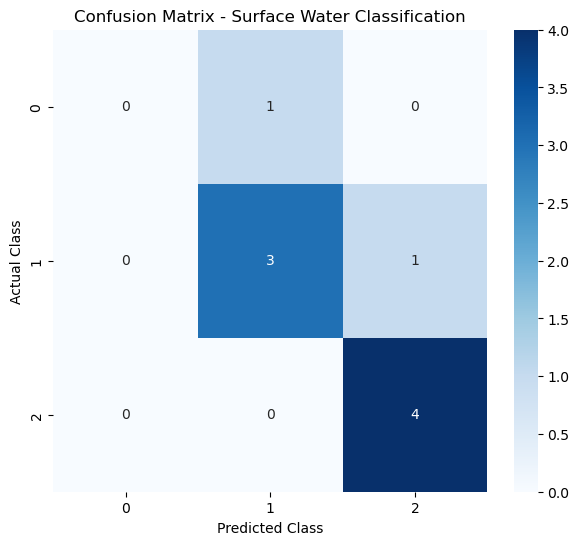

In [34]:
#CONFUSION MATRIX- SURFACE CLASSIFICATION
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Surface Water Classification")

plt.show()

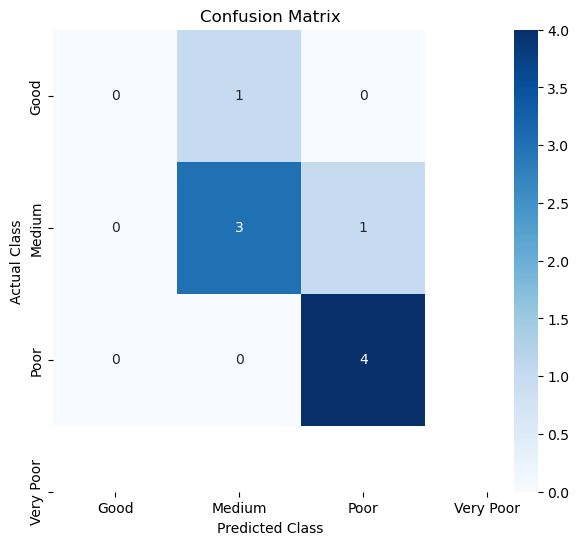

In [36]:
#CONFUSION MATRIX WITH CLASSES- BETTER VERSION
labels = le.classes_

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title("Confusion Matrix")

plt.show()

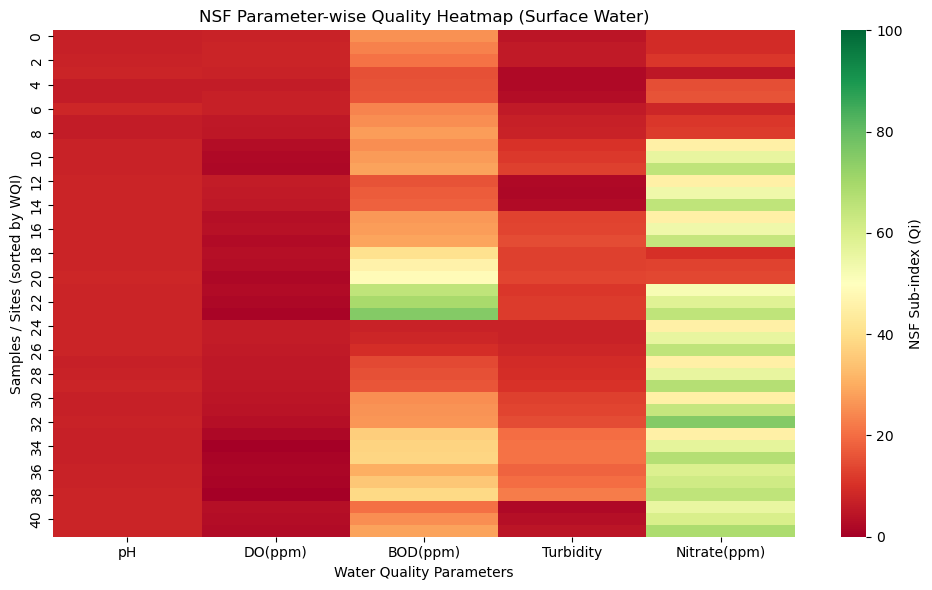

In [39]:
#HEATMAP PLOTTING
qi_cols = [
    "pH",
    "DO(ppm)",
    "BOD(ppm)",
    "Turbidity",
    "Nitrate(ppm)",
    #"TDS",
]

heatmap_data = df[qi_cols]

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",     # red = bad quality, green = good
    vmin=0,
    vmax=100,
    cbar_kws={"label": "NSF Sub-index (Qi)"}
)

plt.title("NSF Parameter-wise Quality Heatmap (Surface Water)")
plt.xlabel("Water Quality Parameters")
plt.ylabel("Samples / Sites (sorted by WQI)")
plt.tight_layout()
plt.show()

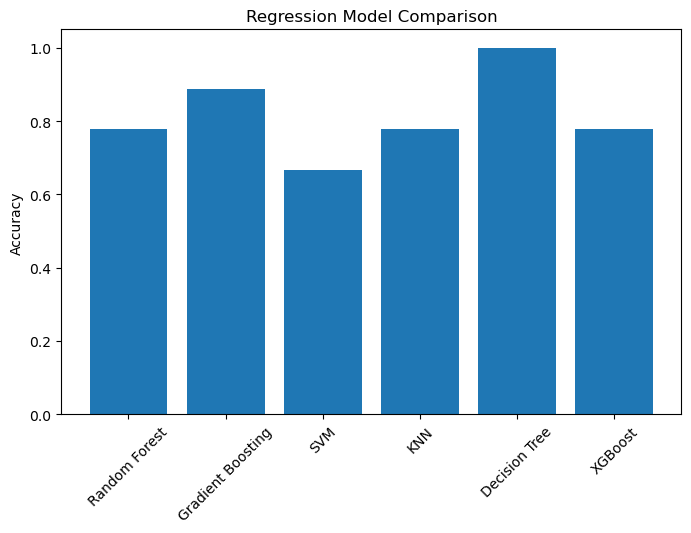

In [40]:
#MODEL COMPEROSSION GRAPH

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Regression Model Comparison")
plt.show()

In [41]:
#SHAP ANALYSIS
import shap
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

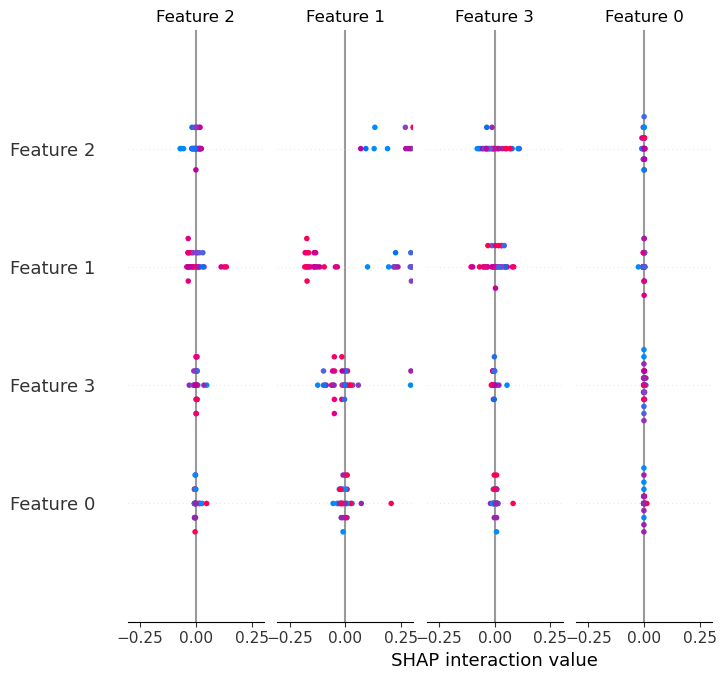

In [44]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)
#PLOT
shap.summary_plot(shap_values, X_train)
#Red - high feature value
#Blue - low feature value